# SBERT Sentence Analysis

## 1. Preparations

### 1.1 Read Data
The sentence data were preprocessed (see preprocessing.ipynb)
In the dataframe:  
- "sentence" = preprocessed sentences with placeholders of anonymized information, **used for the analysis**
- "clean_sentence" = proprocessed sentences with placeholders removed,  
- "translated_sentence" = translated from "sentence" column to English with translate.ipynb

In [1]:
# first install numpy=1.26.4 before installing pandas and other packages
# %pip install numpy=1.26.4
# %pip install pandas openpyxl

import pandas as pd
# read the sentence data 
df = pd.read_excel("/workspace/persistent/mijnidbcoachnlp/data/analysis_data/sentence_data_for_analysis.xlsx", index_col=0)
sentences = df["sentence"].to_list()

# check the df head
df.head()

,message_id,sentence,clean_sentence,sentence_id,translated_sentence
0,1,"Geachte ibd groep, Is mijn uitslag al binnen ...","ibd groep, Is mijn uitslag al binnen van de b...",1,"Dear Ibd group, has my results come back from ..."
1,3,Vorige week is door [ZIEKENHUIS] [LOCATIE] mij...,Vorige week is door mijn ontlasting onderzoc...,2,Last week my stool was examined by [SIGHSHOUSE...
2,3,Graag zou ik de uitkomst hiervan vernemen.,Graag zou ik de uitkomst hiervan vernemen.,3,I would like to hear the outcome of this.
3,4,bloed in de ontlasting wordt steeds meer en st...,bloed in de ontlasting wordt steeds meer en st...,4,blood in the stool is becoming more and more f...
4,4,Ligt dit aan de medicatie?,Ligt dit aan de medicatie?,5,Is this because of the medication?


In [2]:
# check input size
len_data = len(sentences)
print(f"data size: {len_data}")

data size: 41119


In [3]:
### Importing the list of Dutch stopwords (note that there are customized dutch words in there)

with open('/workspace/persistent/mijnidbcoachnlp/data/analysis_data/stopwords_extended.txt', 'r') as file:
    lines = [line.strip() for line in file.readlines()]

dutch_stopwords = lines

In [4]:
# %pip install gensim

import pickle
from gensim.corpora import Dictionary

# Load the tokenized texts
with open("/workspace/persistent/mijnidbcoachnlp/data/tokens/tokenized_sentences.pkl", "rb") as f:
    tokenized_texts = pickle.load(f)

dictionary = Dictionary(tokenized_texts)

### 1.2 Embed the lists of sentences (Commented Out)
In this section, we embed the sentence data with five differen sentence transformer models available on Hugging Face. Only run once.

In [5]:
# %pip install sentence_transformers

from sentence_transformers import SentenceTransformer
from tqdm.autonotebook import tqdm  
import numpy as np
import sentence_transformers.util
import os 
import numpy as np

def embed_and_save(docs, embedding_model, save_path):
    """Generate embeddings for documents and save them with model name in the filename."""
    embeddings = embedding_model.encode(docs, show_progress_bar=True)
    
    # Use model class name as identifier
    model_name = embedding_model.__class__.__name__
    
    # Create the full file path
    file_name = f'embeddings_{model_name}.npy'
    file_path = os.path.join(save_path, file_name)
    
    # Save the embeddings
    np.save(file_path, embeddings)

    # print saved embeddings
    print(f"Embedding saved successfully to {file_path}")

In [6]:
# list of all embedding models to try out
#from sentence_transformers import SentenceTransformer

#embedding_models = [
    #("stv1", SentenceTransformer("distiluse-base-multilingual-cased-v1")),
    #("stv2", SentenceTransformer("distiluse-base-multilingual-cased-v2")),
    #("mini", SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")),
    #("mpnet", SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")),
    #("robbert", SentenceTransformer("NetherlandsForensicInstitute/robbert-2022-dutch-sentence-transformers")),
    #("e5", SentenceTransformer("intfloat/multilingual-e5-large-instruct", trust_remote_code=True))
#]

In [7]:
# embed the documents with all embedding models

#for (name, embedding_model) in embedding_models:
    #save_path = "/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs"
    # embed all the sentences
    #embed_and_save(docs=sentences, embedding_model=embedding_model, save_path=save_path)
    #print("All embeddings saved successfully.")

### 1.3 Load embeddings

In [8]:
import numpy as np
from sentence_transformers import SentenceTransformer

# Define model names and embeddings
models_and_embeddings = [
    ("stv1", SentenceTransformer("distiluse-base-multilingual-cased-v1"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs/embeddings_st_v1_sentence_placeholder.npy")),
    ("stv2", SentenceTransformer("distiluse-base-multilingual-cased-v2"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs/embeddings_st_v2_sentence_placeholder.npy")),
    ("mini", SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs/embeddings_st_miniL12v2_sentence_placeholder.npy")),
    ("mpnet", SentenceTransformer("paraphrase-multilingual-mpnet-base-v2"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs/embeddings_st_mpnet_v2_sentence_placeholder.npy")),
    ("robbert", SentenceTransformer("NetherlandsForensicInstitute/robbert-2022-dutch-sentence-transformers"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs/embeddings_st_robbert2022_sentence_placeholder.npy")),
    ("e5", SentenceTransformer("intfloat/multilingual-e5-large-instruct", trust_remote_code=True), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs/embeddings_e5.npy"))
]

In [9]:
# disable parallelism to avoid some warnings
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

#### 1.4. Initializa BERTopic settings

In [10]:
# %pip install umap-learn hdbscan 

from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# Shared settings with multiple representation models
bertopic_settings = {
    "vectorizer_model": CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 1), token_pattern=r'\b[a-zA-Z]{3,}\b'),
    "calculate_probabilities": False,
    "verbose": False
    #"representation_model": {
        #"Default": "default",  # This uses the default c-TF-IDF representation
        #"KeyBERTInspired": KeyBERTInspired()
    #}
}

## 3. Coarse Grid Search

### 3.1 Preparations for grid search

In [11]:
# sample the sentences and their embeddings for tuning on a smaller sample 

import random

# Set seed for reproducibility
random.seed(1234)

# Sample indices instead of sentences
sample_size = int(0.2 * len(sentences))
sample_indices = random.sample(range(len(sentences)), sample_size)

# Get the sampled sentences and their embeddings
sampled_sentences = [sentences[i] for i in sample_indices]

# create tokens and dictionary for the sample
sampled_tokens = [tokenized_texts[i] for i in sample_indices]
sample_dictionary = Dictionary(sampled_tokens)

sampled_models_and_embeddings = []

for name, embedding_model, embeddings in models_and_embeddings:
    sampled_embeddings = embeddings[sample_indices]
    sampled_models_and_embeddings.append((name, embedding_model, sampled_embeddings))



In [12]:
# function to return top n words 
# function to get top words
from typing import List

def get_top_words(topic_model, top_n: int) -> List[List[str]]:
    """Extract top words for each topic from BERTopic (excluding outliers and empty words)."""
    topics = topic_model.get_topics()  # topics is a dict: {topic_num: [(word, score), ...]}
    top_words = []
    for topic_num, word_score_list in topics.items():
        if topic_num == -1:
            continue  # Skip outlier topic (-1)
        words = [word for word, _ in word_score_list[:top_n] if word.strip()]  # Skip empty words
        if words:  # Only append if the words list is not empty
            top_words.append(words)
    return top_words


In [13]:
# %pip install octis

# functions for diversity, number of topics and coherence
from octis.evaluation_metrics.diversity_metrics import TopicDiversity
from collections import defaultdict
from typing import List

# function to evaluate topic diversity
def get_topic_diversity(top_words, topk=10):
    metric = TopicDiversity(topk=topk)
    diversity_score = metric.score({"topics": top_words}) 
    return diversity_score

# function to calculate coverage
def get_coverage(topic_model):
    """Calculate the proportion of documents assigned to valid topics (topic != -1)."""
    topics = topic_model.topics_
    valid_topic_count = sum(1 for topic in topics if topic != -1)
    return valid_topic_count / len(topics)

def get_nr_topics(topic_model):
    topic_info = topic_model.get_topic_info()
    # Exclude the outlier class (-1) if you want only real topics
    nr_topics = topic_info[topic_info.Topic != -1].shape[0]
    return nr_topics

from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

def get_c_v(topic_model, tokenized_texts, dictionary, top_words):
    
    # Prepare CoherenceModel
    coherence_model = CoherenceModel(
        topics=top_words,
        texts=tokenized_texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    
    # Compute coherence
    coherence_score = coherence_model.get_coherence()
    
    return coherence_score


In [14]:
# functions to calculate embedding coherence
from typing import List, Tuple, Dict
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def cluster_coherence(embeddings: np.ndarray) -> float:
    """
    Compute the average pairwise cosine similarity among embeddings.
    If only one item in cluster, returns NaN.
    """
    n = embeddings.shape[0]
    if n < 2:
        return np.nan
    sim_mat = cosine_similarity(embeddings)
    iu = np.triu_indices(n, k=1)
    return sim_mat[iu].mean()

def get_intra_topic_similarity(
    topic_model, 
    sentences: List[str], 
    embeddings: np.ndarray
) -> Tuple[float, float, Dict[int, float]]:
    document_info = topic_model.get_document_info(sentences)
    clusters = document_info['Topic'].to_list()

    df = pd.DataFrame({
        'sentence': sentences,
        'embedding': list(embeddings),
        'cluster': clusters
    })

    per_topic_similarities = {}
    total_weighted_sim = 0.0
    total_docs = 0
    similarities = []

    for cluster_label, group in df.groupby('cluster'):
        if cluster_label == -1:
            continue  # Skip outlier topic

        embs = np.vstack(group['embedding'].values)
        mean_sim = cluster_coherence(embs)
        cluster_size = len(group)

        if not np.isnan(mean_sim):
            per_topic_similarities[cluster_label] = mean_sim
            similarities.append(mean_sim)

            total_weighted_sim += mean_sim * cluster_size
            total_docs += cluster_size

    # Compute weighted and unweighted averages
    weighted_mean_sim = total_weighted_sim / total_docs if total_docs > 0 else np.nan
    unweighted_mean_sim = np.mean(similarities) if similarities else np.nan

    return weighted_mean_sim, unweighted_mean_sim, per_topic_similarities


In [15]:
# initialize the range of parameters for coarse grid search

min_cluster_sizes = [10, 20, 30, 40]
range_n_components = [5, 10, 15]
range_n_neighbors = [5, 10, 20, 30]

from itertools import product

# Generate all combinations
coarse_param_combinations = list(product(
    min_cluster_sizes, 
    range_n_components,
    range_n_neighbors, 
))

print(f"Total combinations of coarse grid search for each model: {len(coarse_param_combinations)}")

Total combinations of coarse grid search for each model: 36


### 3.1 Coarse search with param combinations and 20% sample docs

In [46]:
# scikit-learn must be upgraded here to avoid dependency conflic
# %pip install -upgrade scikit-learn
# %pip install bertopic

from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic

# function for grid search
def coarse_grid_search(docs, models_and_embeddings, param_combinations, tokenized_texts, dictionary):
    metrics_vs_combination = defaultdict(dict)
    topic_similarities_combination = defaultdict(dict)

    # use sampled docs instead of full docs
    for name, embedding_model, embeddings in models_and_embeddings:

        # search over min_cluster_size
        for combination in param_combinations:

            # access the three params
            min_cluster_size, n_components, n_neighbors = combination
            
            # initialize a topic model with the basic setting
            topic_model = BERTopic(**bertopic_settings)
            
            # update the hdbscan model and umap model with the three parameters
            topic_model.hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean', cluster_selection_method='eom', prediction_data=False)
            topic_model.umap_model = UMAP(n_neighbors=n_neighbors, n_components=n_components, min_dist=0.0, metric='cosine', random_state=42)
            print(f"Tuning model: {name} at param combination: min_cluster_size = {min_cluster_size}, n_components = {n_components}, n_neighbors = {n_neighbors}")

            topics, probs = topic_model.fit_transform(docs, embeddings)


            coverage = get_coverage(topic_model)
            nr_topics = get_nr_topics(topic_model)
            
            print(f"Document: {coverage}")
            print(f"Number of topics: {nr_topics}")


            min_topic_threshold = len(docs) // 200 # min number of topics is set at 200 docs per topic 

            top_words = get_top_words(topic_model, top_n=10)
            
            diversity_score = get_topic_diversity(top_words)
            print(f"Diversity score: {diversity_score}")

            c_v_score = get_c_v(topic_model, tokenized_texts, dictionary, top_words)
            print(f"C_V coherence: {c_v_score}")

            weighted_sim, unweighted_sim, topic_sim_dict = get_intra_topic_similarity(
                topic_model, docs, embeddings
            )
            print(f"Average embedding cosine similarity weighted: {weighted_sim}, unweighted: {unweighted_sim}")
            print(" ")

            metrics_vs_combination[(name, combination)]["min_cluster_size"] = min_cluster_size
            metrics_vs_combination[(name, combination)]["n_components"] = n_components
            metrics_vs_combination[(name, combination)]["n_neighbors"] = n_neighbors
            metrics_vs_combination[(name, combination)]["diversity_score"] = diversity_score
            metrics_vs_combination[(name, combination)]["c_v_score"] = c_v_score

            metrics_vs_combination[(name, combination)]["weighted_avg_sim"] = weighted_sim
            metrics_vs_combination[(name, combination)]["unweighted_avg_sim"] = unweighted_sim
            topic_similarities_combination[(name, combination)]["per_topic_similarities"] = topic_sim_dict
            metrics_vs_combination[(name, combination)]["document_coverage"] = coverage
            metrics_vs_combination[(name, combination)]["number_of_topics"] = nr_topics
    
    return metrics_vs_combination, topic_similarities_combination

In [17]:
# coarse grid search with sampled sentences
# coarse_metrics_results, coarse_similarities_results = coarse_grid_search(docs=sampled_sentences, models_and_embeddings=sampled_models_and_embeddings, param_combinations=coarse_param_combinations, tokenized_texts=sampled_tokens, dictionary=sample_dictionary)


Tuning model: stv1 at param combination: min_cluster_size = 10, n_components = 5, n_neighbors = 5
Document: 0.6968259759211967
Number of topics: 196
Diversity score: 0.6795918367346939
C_V coherence: 0.3728947664959901
Average embedding cosine similarity weighted: 0.3919845581782842, unweighted: 0.41880229115486145
 
Tuning model: stv1 at param combination: min_cluster_size = 10, n_components = 5, n_neighbors = 10
Document: 0.639547610361182
Number of topics: 147
Diversity score: 0.7163265306122449
C_V coherence: 0.37183863531232814
Average embedding cosine similarity weighted: 0.40513399663556776, unweighted: 0.4361790120601654
 
Tuning model: stv1 at param combination: min_cluster_size = 10, n_components = 5, n_neighbors = 20
Document: 0.6079289796911103
Number of topics: 108
Diversity score: 0.7388888888888889
C_V coherence: 0.3491378254455319
Average embedding cosine similarity weighted: 0.38459243015674, unweighted: 0.44921281933784485
 
Tuning model: stv1 at param combination: mi

In [18]:
# save the results
# load the coarse metrics results
#with open('/workspace/persistent/mijnidbcoachnlp/new_analysis/results/coarse_sample_results.pkl', 'wb') as f:
    #pickle.dump(coarse_metrics_results, f)

# load the coarse metrics results
#with open('/workspace/persistent/mijnidbcoachnlp/new_analysis/results/coarse_sample_results_similarities.pkl', 'wb') as f:
    #pickle.dump(coarse_similarities_results, f)

In [18]:
import pandas as pd
import pickle

# load the coarse metrics results
with open('/workspace/persistent/mijnidbcoachnlp/new_analysis/results/coarse_sample_results.pkl', 'rb') as f:
    metric_results = pickle.load(f)

# Flatten the dictionary into a list of records
rows = []
for (name, combination), metrics in metric_results.items():
    row = {
        "model_name": name,
        "combination": combination,
        **metrics  # Unpack all metric keys/values into columns
    }
    rows.append(row)

# Convert to DataFrame
df_coarse = pd.DataFrame(rows)

df_coarse.head()

,model_name,combination,min_cluster_size,n_components,n_neighbors,diversity_score,c_v_score,weighted_avg_sim,unweighted_avg_sim,document_coverage,number_of_topics
0,stv1,"(10, 5, 5)",10,5,5,0.679592,0.372895,0.391985,0.418802,0.696826,196
1,stv1,"(10, 5, 10)",10,5,10,0.716327,0.371839,0.405134,0.436179,0.639548,147
2,stv1,"(10, 5, 20)",10,5,20,0.738889,0.349138,0.384592,0.449213,0.607929,108
3,stv1,"(10, 10, 5)",10,10,5,0.682199,0.380339,0.398175,0.421129,0.682233,191
4,stv1,"(10, 10, 10)",10,10,10,0.726573,0.371346,0.403969,0.445071,0.624346,143


In [50]:
embedding_model = sampled_models_and_embeddings[0][0]
embeddings = sampled_models_and_embeddings[0][2]

combination = (30, 5, 10)

# access the three params
min_cluster_size, n_components, n_neighbors = combination

# initialize a topic model with the basic setting
topic_model = BERTopic(**bertopic_settings)

# update the hdbscan model and umap model with the three parameters
topic_model.hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean', cluster_selection_method='eom', prediction_data=False)
topic_model.umap_model = UMAP(n_neighbors=n_neighbors, n_components=n_components, min_dist=0.0, metric='cosine', random_state=42)
print(f"Tuning model: {embedding_model} at param combination: min_cluster_size = {min_cluster_size}, n_components = {n_components}, n_neighbors = {n_neighbors}")

topics, probs = topic_model.fit_transform(sampled_sentences, embeddings)

coverage = get_coverage(topic_model)
nr_topics = get_nr_topics(topic_model)

print(f"Document: {coverage}")
print(f"Number of topics: {nr_topics}")


Tuning model: stv1 at param combination: min_cluster_size = 30, n_components = 5, n_neighbors = 10
Document: 0.9912440715067493
Number of topics: 5


In [46]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,72,-1_voorbaat_dank_antwoord_bedankt,"[voorbaat, dank, antwoord, bedankt, hulp, info...","[Bij voorbaat dank., Bij voorbaat dank., Bij v..."
1,0,7883,0_beste_graag_hallo_goed,"[beste, graag, hallo, goed, laten, hoi, apothe...","[Beste [PERSOON], Graag zou ik de afspraak aa..."
2,1,100,1_bedankt_alvast_dank_moeite,"[bedankt, alvast, dank, moeite, dankjewel, har...","[Je bent alvast bedankt., Alvast bedankt voor ..."
3,2,78,2_bedankt_reactie_dank_bericht,"[bedankt, reactie, dank, bericht, sorry, dankj...","[Bedankt voor de reactie., Bedankt voor de rea..."
4,3,52,3_snelle_reactie_bedankt_dank,"[snelle, reactie, bedankt, dank, snel, antwoor...","[Bedankt voor de snelle reactie., Bedankt voor..."
5,4,38,4_snelle_reactie_bedankt_dankjewel,"[snelle, reactie, bedankt, dankjewel, dank, be...","[[PERSOON], Bedankt voor de snelle reactie., ..."


In [ ]:
#import pickle

# Save results to a file
#with open('/workspace/persistent/mijnidbcoachnlp/new_analysis/results/coarse_sample_results.pkl', 'wb') as f:
    #pickle.dump(coarse_metrics_results, f)

### 3.2 Observe metric trends over different parameters

In [25]:
len(df_coarse)

129

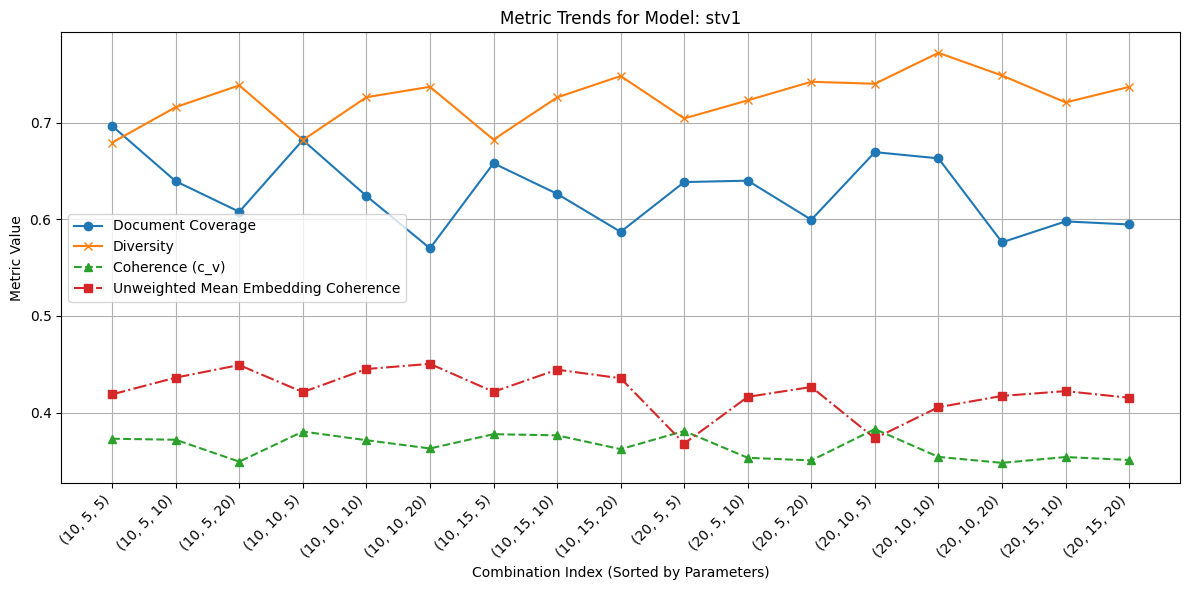

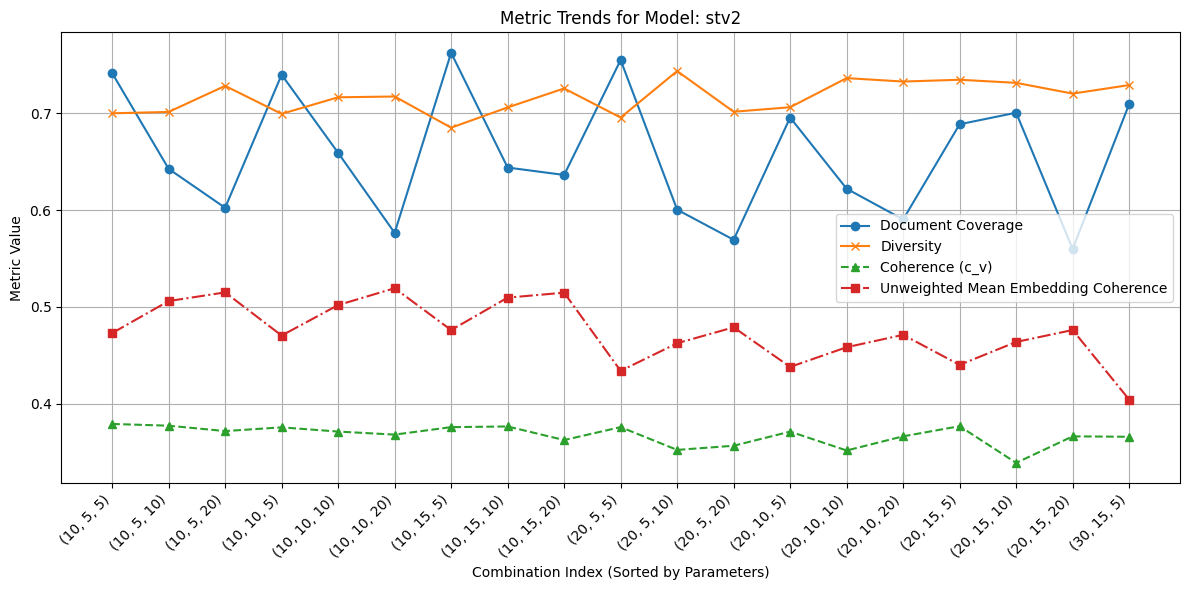

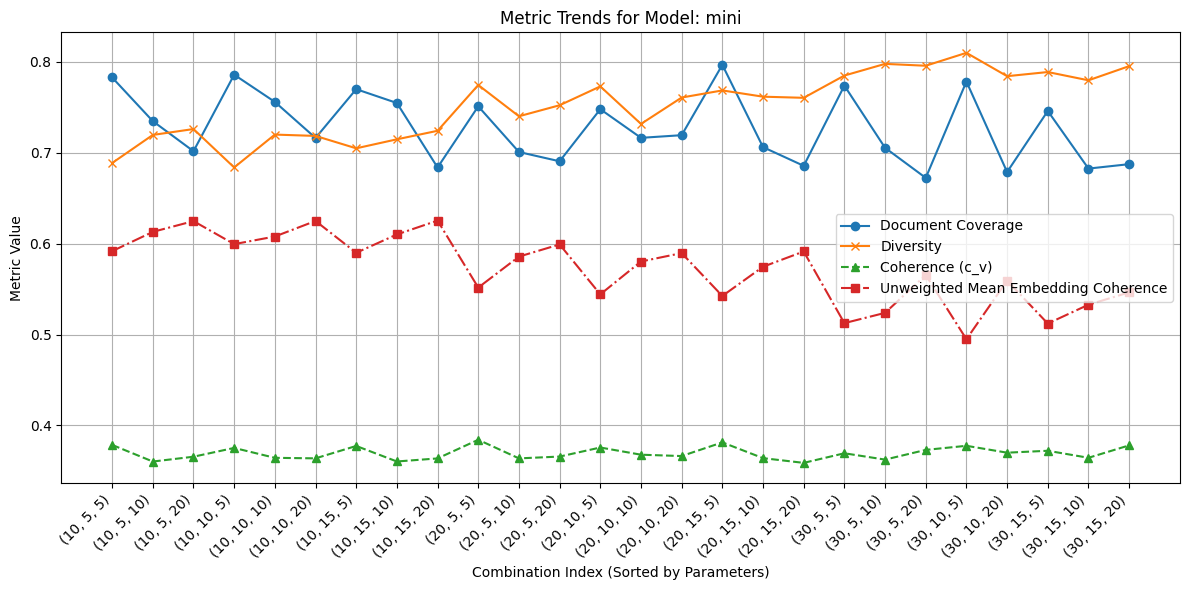

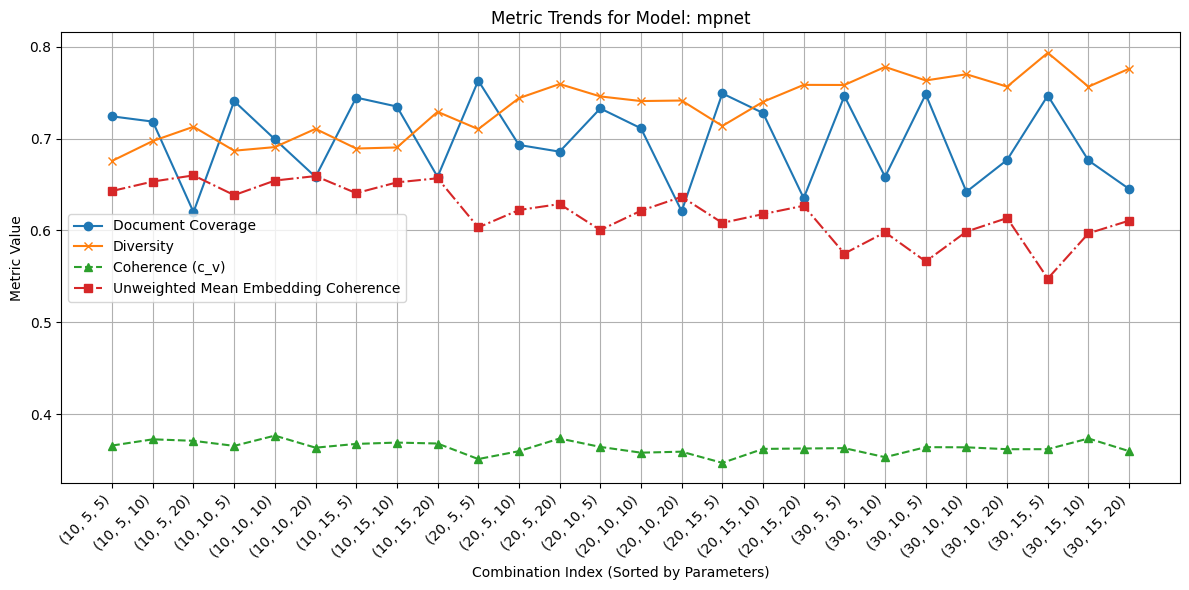

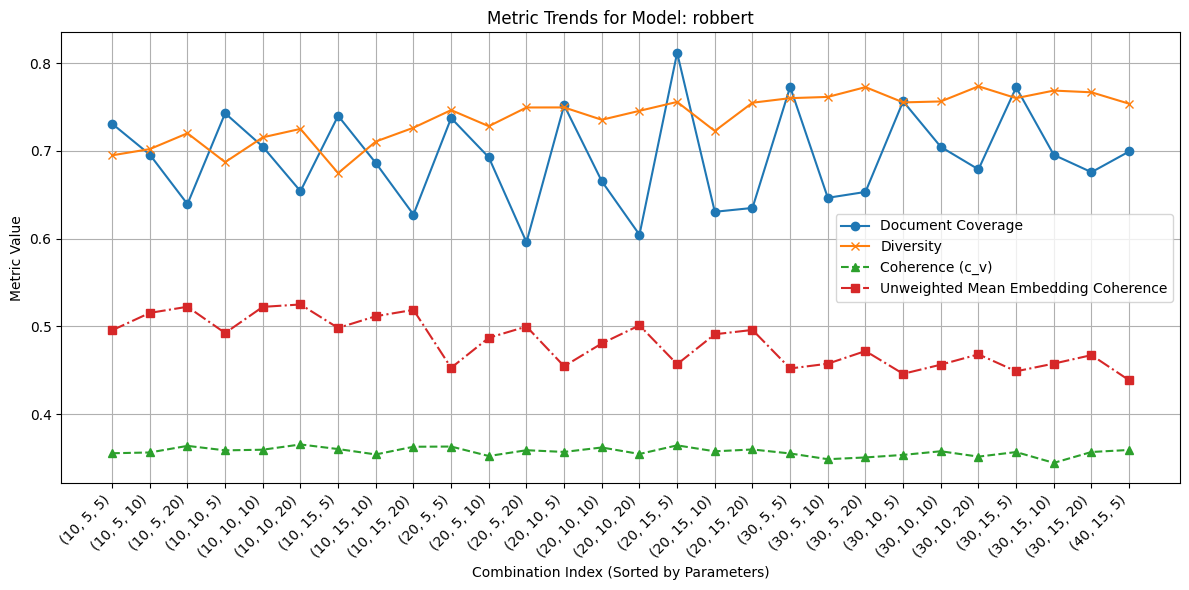

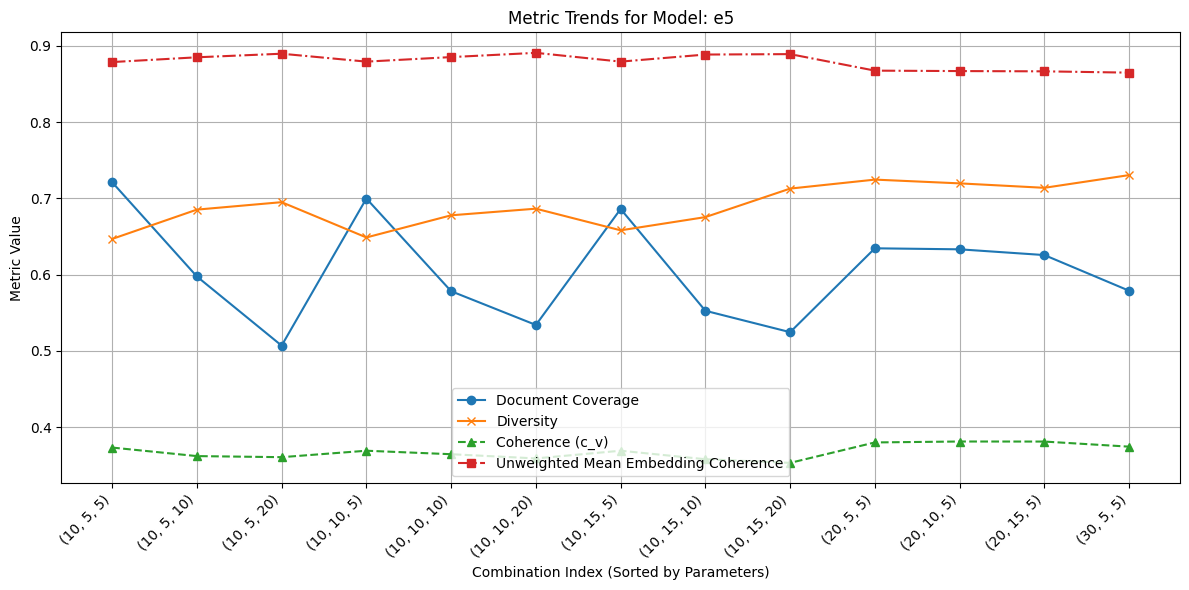

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
df = df_coarse
# Assume df is your main dataframe
models = df['model_name'].unique()

for model in models:
    df_model = df[df['model_name'] == model]
    
    # Sort by parameters to reveal trends
    df_model_sorted = df_model.sort_values(
        by=["min_cluster_size", "n_components", "n_neighbors"]
    ).reset_index(drop=True)

    
    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(df_model_sorted.index, df_model_sorted['document_coverage'], label='Document Coverage', marker='o')
    plt.plot(df_model_sorted.index, df_model_sorted['diversity_score'], label='Diversity', marker='x')
    plt.plot(df_model_sorted.index, df_model_sorted['c_v_score'], label='Coherence (c_v)', linestyle='--', marker='^')
    plt.plot(df_model_sorted.index, df_model_sorted['unweighted_avg_sim'], label='Unweighted Mean Embedding Coherence', linestyle='-.', marker='s')

    
    plt.xticks(ticks=df_model_sorted.index, labels=df_model_sorted['combination'], rotation=45, ha='right')


    plt.title(f'Metric Trends for Model: {model}')
    plt.xlabel('Combination Index (Sorted by Parameters)')
    plt.ylabel('Metric Value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


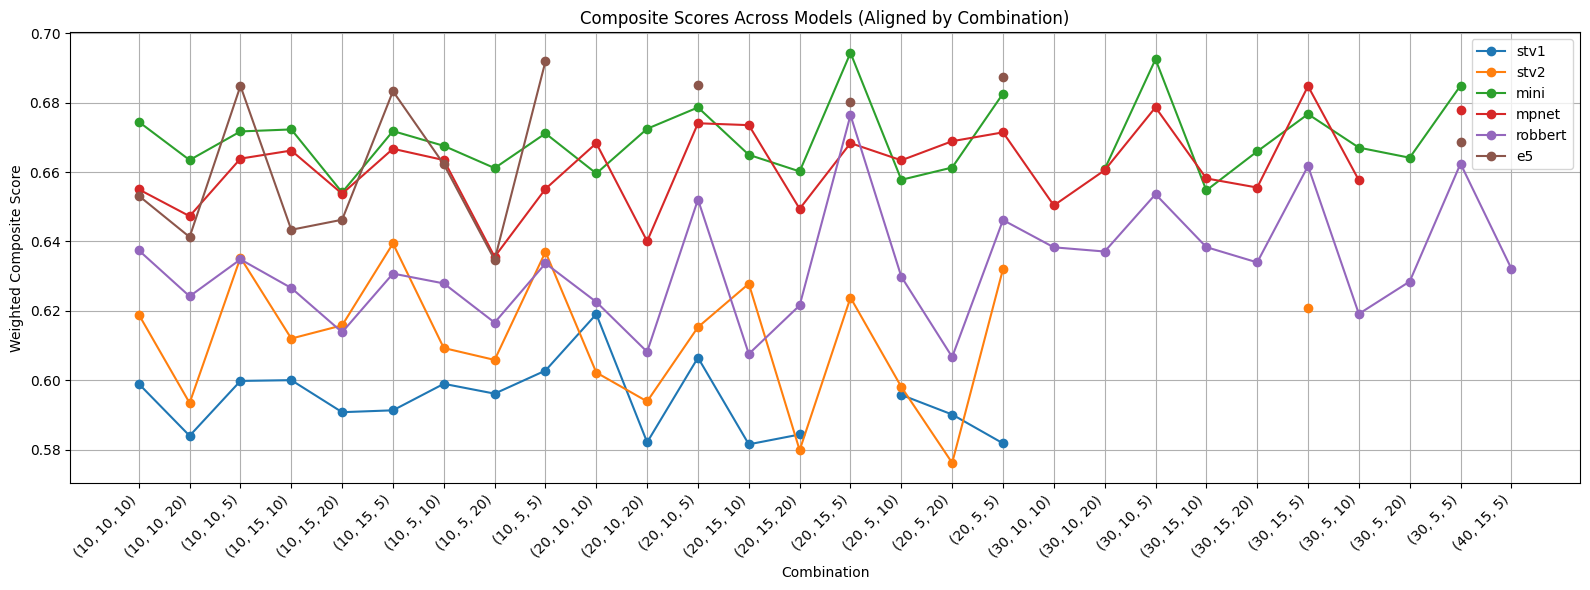

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

# Copy and define weights
df = df_coarse.copy()

weights = {
    'document_coverage': 0.35,
    'diversity_score': 0.35,
    'c_v_score': 0.10,
    'unweighted_avg_sim': 0.20
}

# Ensure 'combination' is string-type
df['combination'] = df['combination'].astype(str)

# Compute weighted composite score
df['weighted_composite_score'] = sum(
    df[metric] * weight for metric, weight in weights.items()
)

# Get all unique combinations in desired order
all_combinations = sorted(df['combination'].unique())

# Initialize plot
plt.figure(figsize=(16, 6))

# Loop over models
for model in df['model_name'].unique():
    df_model = df[df['model_name'] == model][['combination', 'weighted_composite_score']]
    df_model = df_model.set_index('combination').reindex(all_combinations)
    
    plt.plot(
        all_combinations,
        df_model['weighted_composite_score'],
        label=f'{model}',
        marker='o'
    )

# Format x-axis
plt.xticks(rotation=45, ha='right')
plt.xlabel('Combination')
plt.ylabel('Weighted Composite Score')
plt.title('Composite Scores Across Models (Aligned by Combination)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [47]:
from itertools import product

# Define parameter ranges
min_cluster_sizes = [10, 20, 30, 40]
range_n_components = [5, 10, 15]
range_n_neighbors = [5, 10, 20, 30]

# Full space of combinations (tuples)
param_combinations = list(product(
    min_cluster_sizes, 
    range_n_components,
    range_n_neighbors
))

# Convert 'combination' column to tuple if it's currently a string
df['combination_tuple'] = df['combination'].apply(eval) if isinstance(df['combination'].iloc[0], str) else df['combination']

# Get all observed combinations
all_combinations = set(df['combination_tuple'].unique())

# Find combinations that are not yet used
unused_combinations = [
    combo for combo in param_combinations if combo not in all_combinations
]

In [61]:
excl_metrics_results_robbert, excl_similarities_results_robbert = coarse_grid_search(docs=sampled_sentences, models_and_embeddings=sampled_models_and_embeddings[4:5], param_combinations=unused_combinations, tokenized_texts=sampled_tokens, dictionary=sample_dictionary)

Tuning model: robbert at param combination: min_cluster_size = 10, n_components = 5, n_neighbors = 30
Document: 0.606834488629454
Number of topics: 120
Diversity score: 0.735
C_V coherence: 0.35756424053783475
Average embedding cosine similarity weighted: 0.5060337736874162, unweighted: 0.5325843691825867
 
Tuning model: robbert at param combination: min_cluster_size = 10, n_components = 10, n_neighbors = 30
Document: 0.5926061048279216
Number of topics: 118
Diversity score: 0.7220338983050848
C_V coherence: 0.3621362389982451
Average embedding cosine similarity weighted: 0.5083601112889725, unweighted: 0.5340303778648376
 
Tuning model: robbert at param combination: min_cluster_size = 10, n_components = 15, n_neighbors = 30
Document: 0.6063480481576067
Number of topics: 115
Diversity score: 0.7217391304347827
C_V coherence: 0.35881733461440035
Average embedding cosine similarity weighted: 0.5059398909888017, unweighted: 0.5282065272331238
 
Tuning model: robbert at param combination: 

In [55]:
import re
from collections import defaultdict

# Read the content of the file
with open("/workspace/persistent/mijnidbcoachnlp/output.txt", "r", encoding="utf-8") as file:
    output = file.read()

# Initialize dictionary
metrics_vs_combination = defaultdict(dict)

model_param_pattern = re.compile(
    r"Tuning model: (?P<name>\w+) at param combination: min_cluster_size = (?P<min_cluster_size>\d+), "
    r"n_components = (?P<n_components>\d+), n_neighbors = (?P<n_neighbors>\d+)\s*"
    r"Document: (?P<coverage>[\d.]+)\s*"
    r"Number of topics: (?P<nr_topics>\d+)\s*"
    r"Diversity score: (?P<diversity_score>[\d.]+)\s*"
    r"C_V coherence: (?P<c_v_score>[\d.]+)\s*"
    r"Average embedding cosine similarity weighted: (?P<weighted_sim>[\d.]+), unweighted: (?P<unweighted_sim>[\d.]+)\s*",
    re.MULTILINE
)

# Parse and populate the dictionary
for match in model_param_pattern.finditer(output):
    gd = match.groupdict()
    name = gd["name"]
    combination = (
        int(gd["min_cluster_size"]),
        int(gd["n_components"]),
        int(gd["n_neighbors"])
    )
    metrics_vs_combination[(name, combination)]["min_cluster_size"] = int(gd["min_cluster_size"])
    metrics_vs_combination[(name, combination)]["n_components"] = int(gd["n_components"])
    metrics_vs_combination[(name, combination)]["n_neighbors"] = int(gd["n_neighbors"])
    metrics_vs_combination[(name, combination)]["diversity_score"] = float(gd["diversity_score"])
    metrics_vs_combination[(name, combination)]["c_v_score"] = float(gd["c_v_score"])
    metrics_vs_combination[(name, combination)]["weighted_avg_sim"] = float(gd["weighted_sim"])
    metrics_vs_combination[(name, combination)]["unweighted_avg_sim"] = float(gd["unweighted_sim"])
    metrics_vs_combination[(name, combination)]["document_coverage"] = float(gd["coverage"])
    metrics_vs_combination[(name, combination)]["number_of_topics"] = int(gd["nr_topics"])

# Print results (optional)
for key, value in metrics_vs_combination.items():
    print(key, value)


('stv1', (10, 5, 30)) {'min_cluster_size': 10, 'n_components': 5, 'n_neighbors': 30, 'diversity_score': 0.7145833333333333, 'c_v_score': 0.3597604381181085, 'weighted_avg_sim': 0.38817198333810105, 'unweighted_avg_sim': 0.466794490814209, 'document_coverage': 0.5747294174875349, 'number_of_topics': 96}
('stv1', (10, 10, 30)) {'min_cluster_size': 10, 'n_components': 10, 'n_neighbors': 30, 'diversity_score': 0.7339622641509433, 'c_v_score': 0.35932946129606186, 'weighted_avg_sim': 0.41809077226522673, 'unweighted_avg_sim': 0.46751973032951355, 'document_coverage': 0.5403137541043415, 'number_of_topics': 106}
('stv1', (10, 15, 30)) {'min_cluster_size': 10, 'n_components': 15, 'n_neighbors': 30, 'diversity_score': 0.7367924528301887, 'c_v_score': 0.3585258961419301, 'weighted_avg_sim': 0.39573003422023856, 'unweighted_avg_sim': 0.46279096603393555, 'document_coverage': 0.5822692448011675, 'number_of_topics': 106}
('stv1', (20, 5, 30)) {'min_cluster_size': 20, 'n_components': 5, 'n_neighbor

In [56]:
combined = metric_results.copy()
combined.update(metrics_vs_combination)

In [62]:
combined.update(excl_metrics_results_robbert)

In [63]:
# Flatten the dictionary into a list of records
rows = []
for (name, combination), metrics in combined.items():
    row = {
        "model_name": name,
        "combination": combination,
        **metrics  # Unpack all metric keys/values into columns
    }
    rows.append(row)

# Convert to DataFrame
df_add = pd.DataFrame(rows)

df_add.head()

,model_name,combination,min_cluster_size,n_components,n_neighbors,diversity_score,c_v_score,weighted_avg_sim,unweighted_avg_sim,document_coverage,number_of_topics
0,stv1,"(10, 5, 5)",10,5,5,0.679592,0.372895,0.391985,0.418802,0.696826,196
1,stv1,"(10, 5, 10)",10,5,10,0.716327,0.371839,0.405134,0.436179,0.639548,147
2,stv1,"(10, 5, 20)",10,5,20,0.738889,0.349138,0.384592,0.449213,0.607929,108
3,stv1,"(10, 10, 5)",10,10,5,0.682199,0.380339,0.398175,0.421129,0.682233,191
4,stv1,"(10, 10, 10)",10,10,10,0.726573,0.371346,0.403969,0.445071,0.624346,143


In [64]:
len(df_add)

229

In [65]:
#import pickle

# Save results to a file
with open('/workspace/persistent/mijnidbcoachnlp/new_analysis/results/coarse_sample_results_all_except_e5.pkl', 'wb') as f:
    pickle.dump(combined, f)

#### Results for GROW Science Day

In [24]:
'''
from bertopic import BERTopic

embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
embeddings =  np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_st_miniL12v2_sentence_placeholder.npy")

topic_model = BERTopic(**bertopic_settings)
topic_model.hdbscan_model = HDBSCAN(min_cluster_size=25, metric='euclidean', cluster_selection_method='eom', prediction_data=False)
topic_model.umap_model = UMAP(n_neighbors=15, n_components=6, min_dist=0.0, metric='cosine', random_state=42)
topics, probs = topic_model.fit_transform(sentences, embeddings)

'''

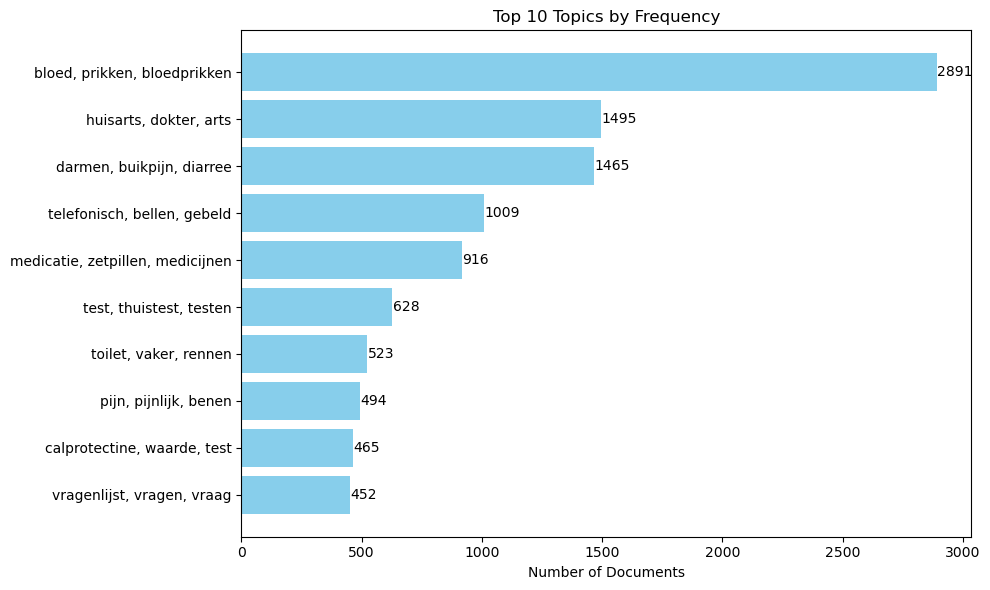

In [31]:
'''
import matplotlib.pyplot as plt

# Get topic info
topic_info = topic_model.get_topic_info()

# Exclude outlier topic -1 and get top 10 topics
top_10 = topic_info[topic_info.Topic != -1].head(10)

# Prepare labels: "Topic #ID: word1, word2, word3"
labels = [f"{', '.join(row['Representation'][:3])}" for _, row in top_10.iterrows()]
frequencies = top_10["Count"].values

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(labels, frequencies, color="skyblue")
plt.xlabel("Number of Documents")
plt.title("Top 10 Topics by Frequency")
plt.gca().invert_yaxis()  # Highest at the top

# Optional: Add counts next to bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 2, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', va='center')

plt.tight_layout()
plt.show()
'''